In [ ]:
# ============================================================
# DISSERTATION: Evaluating Bias and Fairness in Machine Learning
# Models for Diabetes Prediction
# ============================================================
# This script covers:
#   - Data loading and preprocessing
#   - Training three supervised ML models (Logistic Regression,
#     Decision Tree, Random Forest)
#   - Performance evaluation (accuracy, precision, recall, F1)
#   - Fairness evaluation (demographic parity, equal opportunity)
#     across gender and age groups
#   - Visualisations for results chapter
# ============================================================

# ---- Step 1: Install any missing libraries ------------------
# fairlearn is not pre-installed in Colab, so we install it first
!pip install fairlearn --quiet

# ---- Step 2: Import all the libraries we need ---------------
import pandas as pd                          # for loading and manipulating data
import numpy as np                           # for numerical operations
import matplotlib.pyplot as plt              # for plotting charts
import seaborn as sns                        # for nicer-looking charts
import warnings                              # to suppress unnecessary warnings
warnings.filterwarnings('ignore')            # keep the output clean

from sklearn.model_selection import train_test_split          # split data into train/test
from sklearn.preprocessing import LabelEncoder, StandardScaler # encode text columns and scale numbers
from sklearn.linear_model import LogisticRegression           # first ML model
from sklearn.tree import DecisionTreeClassifier               # second ML model
from sklearn.ensemble import RandomForestClassifier           # third ML model
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report,
                             confusion_matrix, ConfusionMatrixDisplay) # performance metrics

from fairlearn.metrics import (demographic_parity_difference,
                                equalized_odds_difference,
                                MetricFrame)                  # fairness metrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 3.8 MB/s eta 0:00:00


In [ ]:
# ============================================================
# SECTION 1: LOAD AND EXPLORE THE DATASET
# ============================================================

# Load the CSV file — upload it to Colab first using the file upload button
df = pd.read_csv('/content/diabetes_prediction_dataset.csv')

# Quick look at the first few rows to make sure it loaded correctly
print("First 5 rows of the dataset:")
print(df.head())

# Check the shape — should be 100,000 rows and 9 columns
print(f"\nDataset shape: {df.shape}")

# Check for missing values — important before training any model
print(f"\nMissing values per column:\n{df.isnull().sum()}")

# See how many people have diabetes vs not — class balance matters
print(f"\nDiabetes class distribution:\n{df['diabetes'].value_counts()}")

# Check the gender column values
print(f"\nGender categories: {df['gender'].unique()}")

# Check smoking history categories
print(f"\nSmoking history categories: {df['smoking_history'].unique()}")

First 5 rows of the dataset:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

Dataset shape: (100000, 9)

Missing values per column:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0


In [ ]:
# ============================================================
# SECTION 2: PREPROCESSING — CLEAN AND PREPARE THE DATA
# ============================================================

# Drop rows where gender is 'Other' — too few records for meaningful fairness analysis
df = df[df['gender'] != 'Other']
print(f"\nDataset size after removing 'Other' gender rows: {df.shape}")

# Encode gender: Male = 1, Female = 0 (needed for fairness grouping later)
df['gender_encoded'] = (df['gender'] == 'Male').astype(int)

# Encode smoking history as numeric categories using LabelEncoder
le_smoke = LabelEncoder()
df['smoking_history_encoded'] = le_smoke.fit_transform(df['smoking_history'])

# Create age groups for fairness analysis — we'll split into two broad groups
# Under 45 = 'Younger', 45 and above = 'Older'
df['age_group'] = (df['age'] >= 45).astype(int)   # 0 = Younger, 1 = Older

# Define the input features (X) and the target label (y)
feature_columns = ['age', 'hypertension', 'heart_disease', 'bmi',
                   'HbA1c_level', 'blood_glucose_level',
                   'smoking_history_encoded', 'gender_encoded']

X = df[feature_columns]    # everything the model learns from
y = df['diabetes']         # what the model is trying to predict

# Scale the numerical features — this helps logistic regression perform better
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # fit on the data and transform it
X_scaled = pd.DataFrame(X_scaled, columns=feature_columns)  # keep column names

# Save the sensitive attributes separately — used for fairness evaluation
gender_attr = df['gender_encoded'].reset_index(drop=True)   # 0 = Female, 1 = Male
age_attr    = df['age_group'].reset_index(drop=True)        # 0 = Younger, 1 = Older




Dataset size after removing 'Other' gender rows: (99982, 9)


In [ ]:
# ============================================================
# SECTION 2B: DESCRIPTIVE STATISTICS FOR DISSERTATION CHAPTER 4
# ============================================================

# Overall dataset size after cleaning
print(f"Final dataset shape after cleaning: {df.shape}")

# Class distribution (diabetic vs non-diabetic), as counts and percentages
print("\nDiabetes class distribution (counts):")
print(df['diabetes'].value_counts())
print("\nDiabetes class distribution (percentages):")
print(df['diabetes'].value_counts(normalize=True) * 100)

# Gender distribution after removing 'Other'
print("\nGender distribution:")
print(df['gender'].value_counts())

# Age group distribution (Younger vs Older)
print("\nAge group distribution:")
print(df['age_group'].value_counts())

# Descriptive statistics for the key continuous variables
print("\nDescriptive statistics for continuous variables:")
print(df[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']].describe())

# Mean values split by diabetes outcome, useful for comparing profiles
print("\nMean values grouped by diabetes outcome:")
print(df.groupby('diabetes')[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']].mean())

Final dataset shape after cleaning: (99982, 12)

Diabetes class distribution (counts):
diabetes
0    91482
1     8500
Name: count, dtype: int64

Diabetes class distribution (percentages):
diabetes
0    91.49847
1     8.50153
Name: proportion, dtype: float64

Gender distribution:
gender
Female    58552
Male      41430
Name: count, dtype: int64

Age group distribution:
age_group
0    52396
1    47586
Name: count, dtype: int64

Descriptive statistics for continuous variables:
                age           bmi   HbA1c_level  blood_glucose_level
count  99982.000000  99982.000000  99982.000000         99982.000000
mean      41.888076     27.320757      5.527529           138.057810
std       22.517206      6.636853      1.070665            40.709469
min        0.080000     10.010000      3.500000            80.000000
25%       24.000000     23.630000      4.800000           100.000000
50%       43.000000     27.320000      5.800000           140.000000
75%       60.000000     29.580000      

In [ ]:
# ============================================================
# SECTION 3: SPLIT DATA INTO TRAINING AND TESTING SETS
# ============================================================

# 80% for training, 20% for testing — standard split in ML research
# random_state ensures reproducibility (same split every time you run it)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Also keep track of the sensitive attributes for the test set
gender_test = gender_attr[X_test.index]   # gender for test rows only
age_test    = age_attr[X_test.index]      # age group for test rows only

print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Testing set size:  {X_test.shape[0]} rows")


Training set size: 79985 rows
Testing set size:  19997 rows


In [ ]:
# ============================================================
# SECTION 4: TRAIN THE THREE MODELS
# ============================================================

# --- Model 1: Logistic Regression ---
# A statistical model that estimates the probability of diabetes
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)                  # train the model
lr_preds = lr_model.predict(X_test)             # make predictions on test set
print("\nLogistic Regression training complete.")

# --- Model 2: Decision Tree ---
# A tree-shaped model that makes decisions based on feature thresholds
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)                  # train the model
dt_preds = dt_model.predict(X_test)             # make predictions on test set
print("Decision Tree training complete.")

# --- Model 3: Random Forest ---
# An ensemble of many decision trees — usually the most accurate
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)                  # train the model
rf_preds = rf_model.predict(X_test)             # make predictions on test set
print("Random Forest training complete.")


Logistic Regression training complete.
Decision Tree training complete.
Random Forest training complete.


In [ ]:
# ============================================================
# SECTION 5: PERFORMANCE EVALUATION
# ============================================================

# Helper function to compute all four metrics for any model
def evaluate_model(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    print(f"\n{name} Performance:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1}

# Evaluate all three models and collect results into a table
results = []
results.append(evaluate_model("Logistic Regression", y_test, lr_preds))
results.append(evaluate_model("Decision Tree",        y_test, dt_preds))
results.append(evaluate_model("Random Forest",        y_test, rf_preds))

# Put results into a DataFrame for easy comparison and export
results_df = pd.DataFrame(results)
print("\n\nOverall Performance Comparison Table:")
print(results_df.to_string(index=False))


Logistic Regression Performance:
  Accuracy:  0.9614
  Precision: 0.8803
  Recall:    0.6318
  F1-Score:  0.7356

Decision Tree Performance:
  Accuracy:  0.9715
  Precision: 0.9669
  Recall:    0.6882
  F1-Score:  0.8041

Random Forest Performance:
  Accuracy:  0.9699
  Precision: 0.9399
  Recall:    0.6900
  F1-Score:  0.7958


Overall Performance Comparison Table:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.961394   0.880328 0.631765  0.735616
      Decision Tree  0.971496   0.966942 0.688235  0.804124
      Random Forest  0.969895   0.939904 0.690000  0.795794


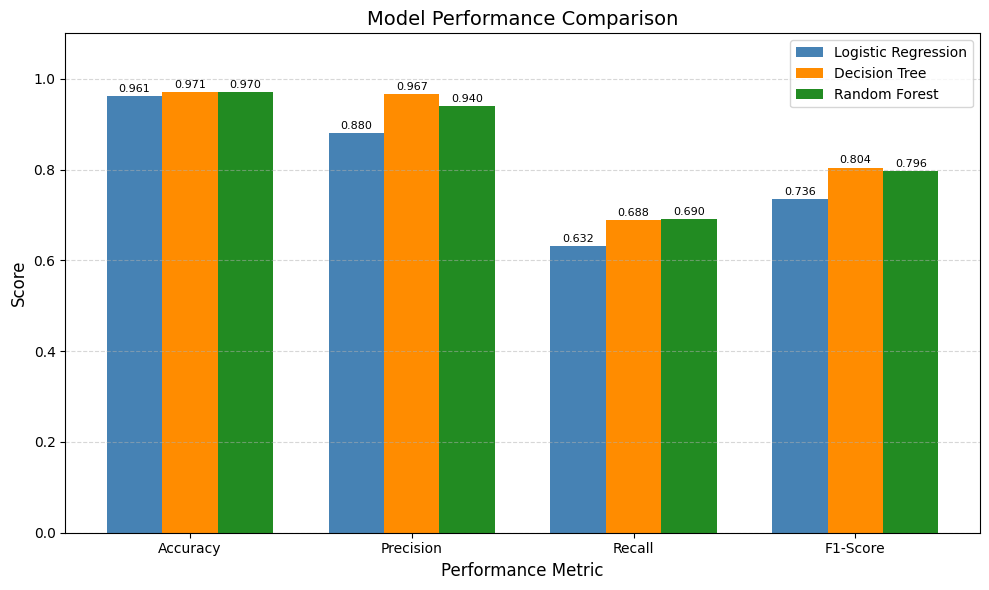

Figure saved: performance_comparison.png


In [ ]:
# ============================================================
# SECTION 6: VISUALISATION 1 — Performance Metrics Bar Chart
# ============================================================

# Compare all three models side-by-side on all four metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))          # label positions on x-axis
width = 0.25                          # width of each bar

fig, ax = plt.subplots(figsize=(10, 6))

# Draw one bar group per model
bars1 = ax.bar(x - width, results_df.iloc[0][metrics], width, label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x,         results_df.iloc[1][metrics], width, label='Decision Tree',        color='darkorange')
bars3 = ax.bar(x + width, results_df.iloc[2][metrics], width, label='Random Forest',        color='forestgreen')

ax.set_xlabel('Performance Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of each bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150)   # save for dissertation
plt.show()
print("Figure saved: performance_comparison.png")

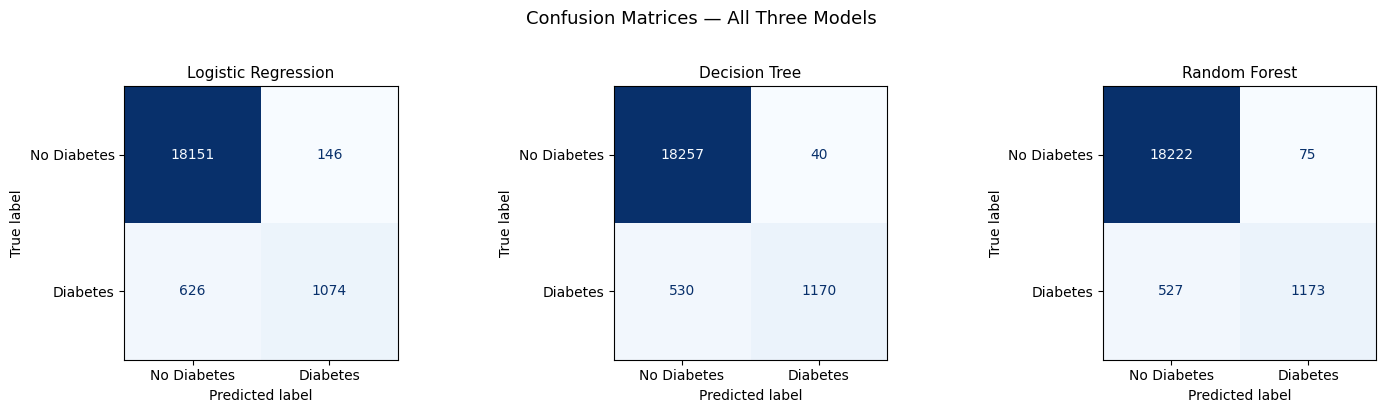

Figure saved: confusion_matrices.png


In [ ]:
# ============================================================
# SECTION 7: VISUALISATION 2 — Confusion Matrices
# ============================================================

# Confusion matrices show exactly where each model makes errors
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
model_names  = ['Logistic Regression', 'Decision Tree', 'Random Forest']
model_preds  = [lr_preds, dt_preds, rf_preds]

for ax, name, preds in zip(axes, model_names, model_preds):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11)

plt.suptitle('Confusion Matrices — All Three Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("Figure saved: confusion_matrices.png")

In [ ]:
# ============================================================
# SECTION 8: FAIRNESS EVALUATION — GENDER
# ============================================================

# We now check whether model predictions are equally fair for Male vs Female patients
# Using two standard fairness metrics:
#   Demographic Parity Difference (DPD): difference in positive prediction rates
#   Equalized Odds Difference (EOD):     difference in true/false positive rates

print("\n\n===== FAIRNESS EVALUATION: GENDER (0=Female, 1=Male) =====")

fairness_gender = []   # store results for all three models

for name, preds in zip(model_names, model_preds):
    dpd = demographic_parity_difference(y_test, preds, sensitive_features=gender_test)
    eod = equalized_odds_difference(y_test, preds, sensitive_features=gender_test)
    print(f"\n{name}:")
    print(f"  Demographic Parity Difference:  {dpd:.4f}")
    print(f"  Equalized Odds Difference:      {eod:.4f}")
    fairness_gender.append({'Model': name, 'DPD (Gender)': abs(dpd), 'EOD (Gender)': abs(eod)})

fairness_gender_df = pd.DataFrame(fairness_gender)



===== FAIRNESS EVALUATION: GENDER (0=Female, 1=Male) =====

Logistic Regression:
  Demographic Parity Difference:  0.0194
  Equalized Odds Difference:      0.0308

Decision Tree:
  Demographic Parity Difference:  0.0158
  Equalized Odds Difference:      0.0134

Random Forest:
  Demographic Parity Difference:  0.0144
  Equalized Odds Difference:      0.0009


In [ ]:
# ============================================================
# SECTION 9: FAIRNESS EVALUATION — AGE GROUP
# ============================================================

# Now check fairness across age groups: Younger (<45) vs Older (45+)
print("\n\n===== FAIRNESS EVALUATION: AGE GROUP (0=Younger <45, 1=Older 45+) =====")

fairness_age = []   # store results for all three models

for name, preds in zip(model_names, model_preds):
    dpd = demographic_parity_difference(y_test, preds, sensitive_features=age_test)
    eod = equalized_odds_difference(y_test, preds, sensitive_features=age_test)
    print(f"\n{name}:")
    print(f"  Demographic Parity Difference:  {dpd:.4f}")
    print(f"  Equalized Odds Difference:      {eod:.4f}")
    fairness_age.append({'Model': name, 'DPD (Age)': abs(dpd), 'EOD (Age)': abs(eod)})

fairness_age_df = pd.DataFrame(fairness_age)



===== FAIRNESS EVALUATION: AGE GROUP (0=Younger <45, 1=Older 45+) =====

Logistic Regression:
  Demographic Parity Difference:  0.1074
  Equalized Odds Difference:      0.2061

Decision Tree:
  Demographic Parity Difference:  0.0988
  Equalized Odds Difference:      0.0265

Random Forest:
  Demographic Parity Difference:  0.1024
  Equalized Odds Difference:      0.0286


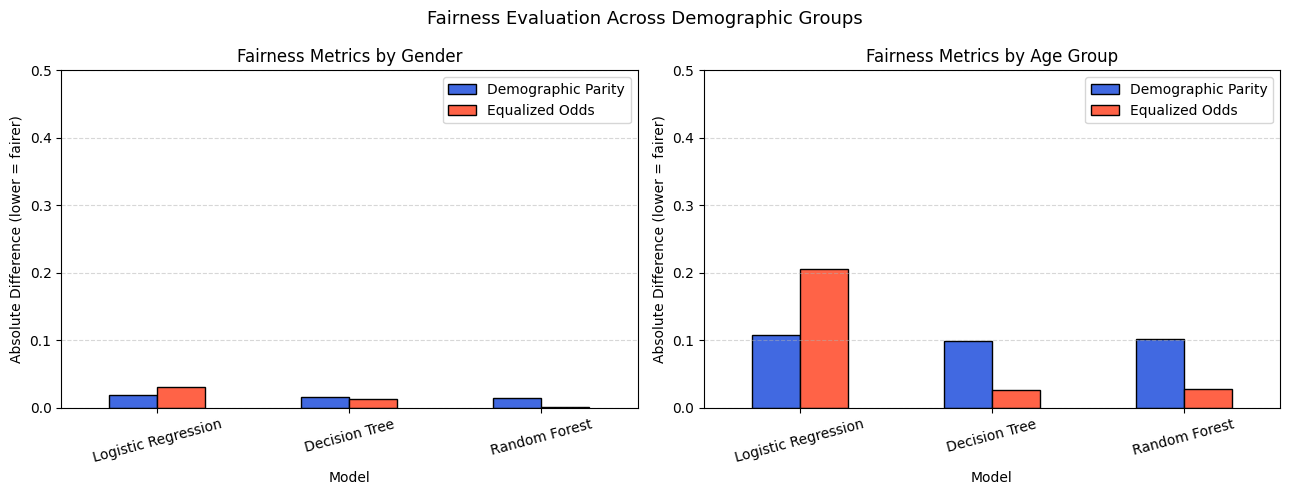

Figure saved: fairness_comparison.png


In [ ]:
# ============================================================
# SECTION 10: VISUALISATION 3 — Fairness Metrics Bar Chart
# ============================================================

# Plot fairness scores side by side — lower values mean fairer models
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gender fairness chart
fairness_gender_df.set_index('Model')[['DPD (Gender)', 'EOD (Gender)']].plot(
    kind='bar', ax=axes[0], color=['royalblue', 'tomato'], edgecolor='black')
axes[0].set_title('Fairness Metrics by Gender', fontsize=12)
axes[0].set_ylabel('Absolute Difference (lower = fairer)', fontsize=10)
axes[0].set_ylim(0, 0.5)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(['Demographic Parity', 'Equalized Odds'])
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Age fairness chart
fairness_age_df.set_index('Model')[['DPD (Age)', 'EOD (Age)']].plot(
    kind='bar', ax=axes[1], color=['royalblue', 'tomato'], edgecolor='black')
axes[1].set_title('Fairness Metrics by Age Group', fontsize=12)
axes[1].set_ylabel('Absolute Difference (lower = fairer)', fontsize=10)
axes[1].set_ylim(0, 0.5)
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(['Demographic Parity', 'Equalized Odds'])
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Fairness Evaluation Across Demographic Groups', fontsize=13)
plt.tight_layout()
plt.savefig('fairness_comparison.png', dpi=150)
plt.show()
print("Figure saved: fairness_comparison.png")



===== PER-GROUP ACCURACY BY GENDER =====
  Logistic Regression — Female: 0.9651
  Logistic Regression — Male: 0.9562
  Decision Tree — Female: 0.9740
  Decision Tree — Male: 0.9680
  Random Forest — Female: 0.9727
  Random Forest — Male: 0.9659


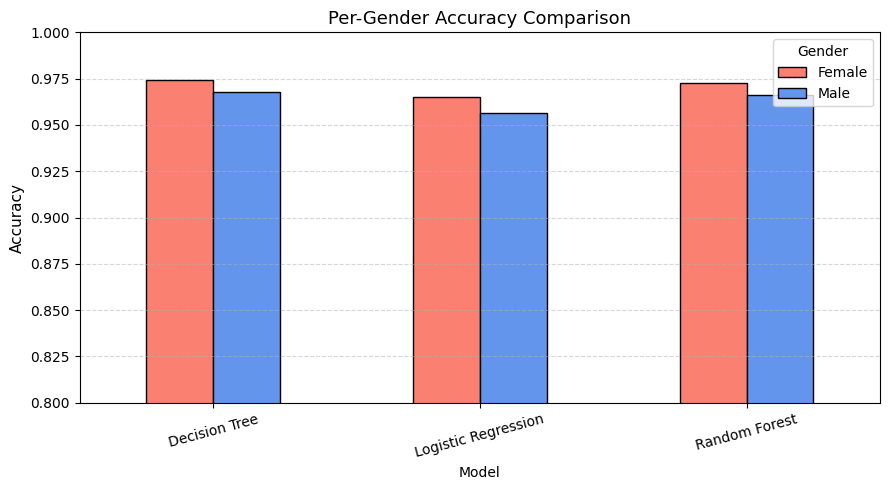

Figure saved: gender_accuracy.png


In [ ]:
# ============================================================
# SECTION 11: VISUALISATION 4 — Per-Group Accuracy (Gender)
# ============================================================

# Reset indices so that y_test, predictions, and sensitive attributes all line up
y_test_reset     = y_test.reset_index(drop=True)       # reset y_test index to 0,1,2...
gender_test_reset = gender_test.reset_index(drop=True)  # reset gender index to match
age_test_reset    = age_test.reset_index(drop=True)     # reset age index to match

print("\n\n===== PER-GROUP ACCURACY BY GENDER =====")

gender_accuracy_data = []

for name, preds in zip(model_names, model_preds):
    preds_series = pd.Series(preds)                        # no index needed, already 0,1,2...
    for gender_val, label in [(0, 'Female'), (1, 'Male')]:
        mask = gender_test_reset == gender_val             # boolean mask now aligns correctly
        group_acc = accuracy_score(y_test_reset[mask], preds_series[mask])
        print(f"  {name} — {label}: {group_acc:.4f}")
        gender_accuracy_data.append({'Model': name, 'Gender': label, 'Accuracy': group_acc})

gender_acc_df = pd.DataFrame(gender_accuracy_data)

# Plot per-gender accuracy
fig, ax = plt.subplots(figsize=(9, 5))
gender_pivot = gender_acc_df.pivot(index='Model', columns='Gender', values='Accuracy')
gender_pivot.plot(kind='bar', ax=ax, color=['salmon', 'cornflowerblue'], edgecolor='black')
ax.set_title('Per-Gender Accuracy Comparison', fontsize=13)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_ylim(0.8, 1.0)
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Gender')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('gender_accuracy.png', dpi=150)
plt.show()
print("Figure saved: gender_accuracy.png")




===== PER-GROUP ACCURACY BY AGE GROUP =====
  Logistic Regression — Younger (<45): 0.9876
  Logistic Regression — Older (45+): 0.9319
  Decision Tree — Younger (<45): 0.9929
  Decision Tree — Older (45+): 0.9474
  Random Forest — Younger (<45): 0.9927
  Random Forest — Older (45+): 0.9443


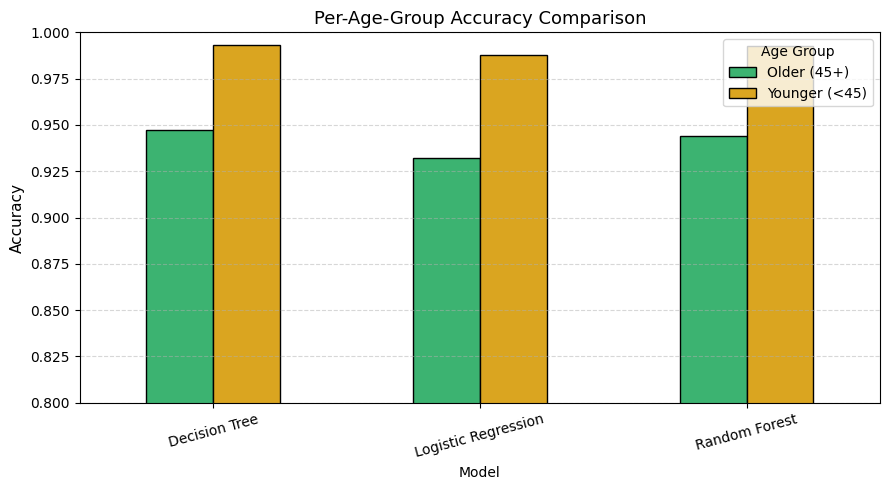

Figure saved: age_accuracy.png


In [ ]:
# ============================================================
# SECTION 12: VISUALISATION 5 — Per-Group Accuracy (Age)
# ============================================================

print("\n\n===== PER-GROUP ACCURACY BY AGE GROUP =====")

age_accuracy_data = []

for name, preds in zip(model_names, model_preds):
    preds_series = pd.Series(preds)                        # fresh series with default index
    for age_val, label in [(0, 'Younger (<45)'), (1, 'Older (45+)')]:
        mask = age_test_reset == age_val                   # mask now aligns correctly
        group_acc = accuracy_score(y_test_reset[mask], preds_series[mask])
        print(f"  {name} — {label}: {group_acc:.4f}")
        age_accuracy_data.append({'Model': name, 'Age Group': label, 'Accuracy': group_acc})

age_acc_df = pd.DataFrame(age_accuracy_data)

# Plot per-age accuracy
fig, ax = plt.subplots(figsize=(9, 5))
age_pivot = age_acc_df.pivot(index='Model', columns='Age Group', values='Accuracy')
age_pivot.plot(kind='bar', ax=ax, color=['mediumseagreen', 'goldenrod'], edgecolor='black')
ax.set_title('Per-Age-Group Accuracy Comparison', fontsize=13)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_ylim(0.8, 1.0)
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Age Group')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('age_accuracy.png', dpi=150)
plt.show()
print("Figure saved: age_accuracy.png")

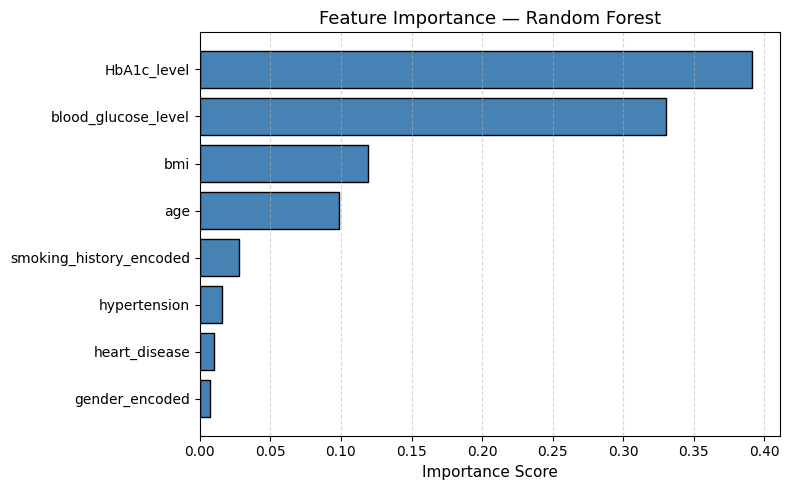

Figure saved: feature_importance.png


In [ ]:
# ============================================================
# SECTION 13: VISUALISATION 6 — Feature Importance (Random Forest)
# ============================================================

# Random Forest can tell us which features matter most for prediction
# This is useful to discuss in the dissertation analysis chapter
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
}).sort_values('Importance', ascending=True)   # sort for horizontal bar chart

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
        color='steelblue', edgecolor='black')
ax.set_title('Feature Importance — Random Forest', fontsize=13)
ax.set_xlabel('Importance Score', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Figure saved: feature_importance.png")

In [ ]:
# ============================================================
# SECTION 14: FINAL SUMMARY TABLE
# ============================================================

# Merge performance and fairness results into one clean summary table
summary = results_df.merge(fairness_gender_df, on='Model').merge(fairness_age_df, on='Model')
print("\n\n===== COMPLETE RESULTS SUMMARY =====")
print(summary.to_string(index=False))

# Save the summary table to a CSV for your dissertation appendix
summary.to_csv('dissertation_results_summary.csv', index=False)



===== COMPLETE RESULTS SUMMARY =====
              Model  Accuracy  Precision   Recall  F1-Score  DPD (Gender)  EOD (Gender)  DPD (Age)  EOD (Age)
Logistic Regression  0.961394   0.880328 0.631765  0.735616      0.019439      0.030822   0.107448   0.206064
      Decision Tree  0.971496   0.966942 0.688235  0.804124      0.015770      0.013354   0.098760   0.026525
      Random Forest  0.969895   0.939904 0.690000  0.795794      0.014363      0.000932   0.102393   0.028554
